<a href="https://colab.research.google.com/github/aqlaboratory/openfold-3/blob/main/examples/template_kinase_example_notebook/2026_of3_multistate_kinase_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OpenFold3 Multistate for Kinases — CIF Direct Template Mode

Kinase-conformation–specific structure prediction with **OpenFold3** ([aqlaboratory/openfold-3](https://github.com/aqlaboratory/openfold-3)), using the **CIF Direct Template Mode** added in [PR #37](https://github.com/aqlaboratory/openfold-3/pull/37).

Stay tuned for a future AF2-specific Kinase notebook and preprint for citing! This notebook is a conceptual port of that approach.

DFG / conformational states follow [Modi & Dunbrack 2022, NAR](https://academic.oup.com/nar/article/50/D1/D654/6395339) and the [Kincore](http://dunbrack.fccc.edu/kincore/) classification.

## Pipeline

1. Pick a kinase sequence + target DFG state.
2. Download the **state-specific Kincore DB** (the `kinase100.<state>_a3m.ff{data,index}` files — Kincore's per-state list of chains that adopt that DFG conformation) and the shared mmCIF coordinate set.
3. Select templates from the state-filtered list. Three strategies are supported (chosen by `template_search_method` in Cell 2):
   - **local** (default, ~1 s): rank state-specific candidates locally by query↔template 4-mer overlap.
   - **all_in_state**: skip ranking; pass the first *N* state-specific CIFs to OpenFold3 and let CIF Direct Mode do `seq_identity × coverage` ranking internally.
   - **hhsearch_regen** (~30 s extra on first run): regenerate the missing `_cs219` files via `cstranslate` and run HHsearch exactly as AF2-multistate does.
   In all strategies the conformational filtering is preserved — we only ever look at templates from the chosen state's ffindex.
4. Pass the selected *(entry, chain)* pairs to OpenFold3 as `template_cif_paths` + `template_cif_chain_ids` (CIF Direct Mode, PR #37 — no separately precomputed alignment file required).
5. Run OpenFold3 inference (diffusion sampling) with the ColabFold MSA server for the input MSA.
6. Visualize models and confidence metrics.

## Why we don't run HHsearch by default

The Kincore OSF tarballs only ship `_a3m.ff{data,index}` — HHsearch's `_cs219` (prefilter) and `_hhm` (per-template HMMs) files are NOT included. A vanilla HHsearch call therefore crashes with `could not open file ..._cs219.ffdata`. The `local` strategy sidesteps this entirely; `hhsearch_regen` regenerates `_cs219` on the fly with `cstranslate` if you want a faithful AF2-multistate reproduction.

## Note on the ColabFold mmseqs2 server

The ColabFold mmseqs2 server is already used inside OpenFold3 inference for the *MSA* (via `--use-msa-server` in Cell 8) — you do not need to call it yourself. It is *not* a substitute for state-specific template selection (ColabFold returns PDB70 hits, not Kincore state-filtered hits), which is what this cell handles.

## GPU requirements

OpenFold3 inference requires **CUDA ≥ 12.1 and ≥ 32 GB GPU memory** (A100 40 GB recommended). On Colab, choose the **A100** runtime under *Runtime → Change runtime type*. T4/V100 will OOM at typical kinase lengths even with `low_mem` enabled.

## How this differs from the AF2 notebook

| AF2-multistate notebook                                  | This OpenFold3 notebook                                                  |
| -------------------------------------------------------- | ------------------------------------------------------------------------ |
| ColabFold + JAX/haiku pins                               | `pip install openfold3[cuequivariance]` + `setup_openfold`               |
| HHsearch ranks state-specific templates                  | Local k-mer ranking by default (HHsearch optional, see Cell 7)           |
| Templates passed to AF2 via HHsearch alignment (.hhr)    | Templates passed to OF3 via `template_cif_paths` (CIF Direct Mode)       |
| `colabfold_runner.run(...)` (Python API)                 | `run_openfold predict ...` (CLI)                                         |
| 5 model variants × 5 recycles                            | `num_diffusion_samples` × `num_model_seeds` (diffusion sampler)          |

Both pipelines use the **same Kincore state-specific template list** (`kinase100.<state>_a3m.ffindex`) as the source of conformationally-screened candidate chains, ensuring conformationally-equivalent template input to both models.


In [ ]:
# @title 0. Environment variables — run FIRST

import os
import sys

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["TF_FORCE_UNIFIED_MEMORY"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["OPENFOLD_CACHE"] = os.path.expanduser("~/.openfold3")

# Capture THIS kernel's Python interpreter so the install cell's `pip` calls
# always land in the right site-packages, regardless of what's first on PATH.
# Without this, prepending /opt/conda/bin (for HH-suite) below would also
# make `pip install py3Dmol` resolve to Miniforge's pip (Python 3.13), while
# the kernel actually runs Python 3.12 at /usr/local/lib/. The Cell 9 viewer
# then fails with ModuleNotFoundError because py3Dmol is in the wrong env.
os.environ["KERNEL_PYTHON"] = sys.executable
print(f"Kernel Python:  {sys.executable}")
print(f"Python version: {sys.version.split()[0]}")

# Make sure /opt/conda/bin (Miniforge's HH-suite) and /usr/local/bin
# (where the install cell symlinks the conda binaries) are on PATH so
# subprocess.run("hhsearch", ...) etc. resolves. The KERNEL_PYTHON capture
# above protects pip-install commands from being hijacked by conda's pip.
_extra_paths = ["/opt/conda/bin", "/usr/local/bin"]
_existing = os.environ.get("PATH", "").split(":")
for _p in reversed(_extra_paths):
    if _p not in _existing:
        os.environ["PATH"] = _p + ":" + os.environ["PATH"]

print("\nPATH now includes:")
for _p in _extra_paths:
    print(
        f"  {_p}  ({'on PATH' if _p in os.environ['PATH'].split(':') else 'MISSING'})"
    )
print("\nNow run the input configuration cell.")

Kernel Python:  /home/jandom/workspace/openfold-3/.pixi/envs/openfold3-cuda13/bin/python
Python version: 3.14.6

PATH now includes:
  /opt/conda/bin  (on PATH)
  /usr/local/bin  (on PATH)

Now run the input configuration cell.


In [2]:
# @title 0b. Make helpers.py importable (Colab bootstrap)
# The reusable pure-Python logic for this notebook lives in helpers.py next to
# the notebook (and is unit-tested in test_helpers.py). On Colab that file is
# not present until we fetch it; locally it already sits beside the notebook,
# so the guard below is a no-op.
import pathlib
import subprocess

if not pathlib.Path("helpers.py").exists():
    url = (
        "https://raw.githubusercontent.com/aqlaboratory/openfold-3/main/"
        "examples/notebooks/2026-multistate_kinase_generation/helpers.py"
    )
    subprocess.run(["wget", "-q", "-O", "helpers.py", url], check=True)
    print("Fetched helpers.py from GitHub.")

import helpers

print(f"helpers loaded from {helpers.__file__}")

helpers loaded from /home/jandom/workspace/openfold-3/examples/notebooks/2026-multistate_kinase_generation/helpers.py


In [3]:
# @title 1. Input configuration  { run: "auto", display-mode: "form" }

import pathlib

import helpers

# @markdown ### Required
query_sequence = "ATQAVHEFAKELDATNISIDKVVGAGEFGEVCSGRLKLPSKKEISVAIKTLKVGYTEKQRRDFLGEASIMGQFDHPNIIRLEGVVTKSKPVMIVTEYMENGSLDSFLRKHDAQFTVIQLVGMLRGIASGMKYLSDMGYVHRDLAARNILINSNLVCKVSDFGLSRVLEDDPEAAYTTRGGKIPIRWTSPEAIAYRKFTSASDVWSYGIVLWEVMSYGERPYWEMSNQDVIKAVDEGYRLPPPMDCPAALYQLMLDCWQKDRNNRPKFEQIVSILDKLIRNPGSLKIITSAAARPSNLLLDQSNVDITTFRTTGDWLNGVWTAHCKEIFTGVEYSSCDT"  # @param {type:"string"}
jobname = "EphA3_DFGin_BBAminus_OF3_MSA"  # @param {type:"string"}

# @markdown ### DFG conformational state (Modi & Dunbrack / Kincore)
kinase_state = "DFGout_BBAminus"  # @param ["DFGin_BLAminus", "DFGin_BLAplus", "DFGin_BLBminus", "DFGin_BLBplus", "DFGin_BLBtrans", "DFGin_ABAminus", "DFGin_All", "DFGin_Other", "DFGinter_BABtrans", "DFGinter_All", "DFGinter_Other", "DFGout_BBAminus", "DFGout_All", "DFGout_Other", "Other_All"]

# @markdown ### OpenFold3 sampling
num_diffusion_samples = 5  # @param [1, 2, 3, 5, 10] {type:"raw"}
num_model_seeds = 1  # @param [1, 2, 3] {type:"raw"}

# @markdown ### Templates
num_templates = 10  # @param [4, 8, 10, 15, 20] {type:"raw"}
# @markdown Template selection strategy (Kincore OSF DB ships only `_a3m.ff{data,index}` — HHsearch's `_cs219` and `_hhm` files are missing, so the original AF2-multistate HHsearch call fails out of the box):
# @markdown - **local** (default, fast): rank state-specific templates by query↔template 4-mer overlap in pure Python. Conformational filtering is preserved because we only look in the state-specific ffindex.
# @markdown - **all_in_state**: skip ranking entirely; pass the first N state-specific CIFs to OpenFold3 and let CIF Direct Mode rank by `seq_identity × coverage`.
# @markdown - **hhsearch_regen**: regenerate the missing `_cs219` files with `cstranslate` (~30 s) and run HHsearch. Matches AF2-multistate exactly but pays the rebuild cost on first run.
template_search_method = "local"  # @param ["local", "all_in_state", "hhsearch_regen"]

# @markdown ### MSA mode
# @markdown - **msa_server** (default): fetch MSA from ColabFold mmseqs2 server. Highest accuracy for monomer structure prediction but for kinases the MSA tends to encode the dominant *active* (BLAminus) conformation across the entire kinome, which can wash out the state-specific template signal.
# @markdown - **msa_free**: skip MSA generation. Diffusion is then dominated by template signal alone. Recommended if you find `msa_server` always returns the same conformation regardless of which Kincore state you pick.
msa_mode = "msa_free"  # @param ["msa_server", "msa_free"]
use_msa_server = msa_mode == "msa_server"

# @markdown ### Memory / IO
use_low_mem = False  # @param {type:"boolean"}
save_to_google_drive = False  # @param {type:"boolean"}

conformational_state = kinase_state


query_sequence = helpers.sanitize_sequence(query_sequence)
jobname = helpers.sanitize_jobname(jobname)
assert len(query_sequence) >= 16, "Query too short."

pathlib.Path(jobname).mkdir(exist_ok=True)
print(f"Job: {jobname}  ({len(query_sequence)} aa, state={kinase_state})")
print(
    f"OF3 sampling: {num_diffusion_samples} diffusion samples × {num_model_seeds} seed(s)"
)
print(f"Templates: top {num_templates} from kinase100.{kinase_state}")

Job: EphA3_DFGin_BBAminus_OF3_MSA  (338 aa, state=DFGout_BBAminus)
OF3 sampling: 5 diffusion samples × 1 seed(s)
Templates: top 10 from kinase100.DFGout_BBAminus


In [5]:
#@title 2. Install OpenFold3 + HH-suite + viz deps
%%bash -s $use_low_mem

set -e

# --- Colab-only guard -----------------------------------------------------
# This cell installs OpenFold3, Miniforge and HH-suite into system paths —
# only appropriate on a disposable Colab VM. On a local/dev machine (where
# openfold3 is already in the kernel env) skip it entirely.
if [ -z "${COLAB_RELEASE_TAG:-}" ] && [ ! -d /content ]; then
  echo "Not on Colab — skipping OpenFold3 / HH-suite / viz install."
  exit 0
fi

USE_LOW_MEM=$1

# --- [1/4] Install OpenFold3 from GitHub @ the PR #37 merge commit --------
# IMPORTANT: PyPI's `openfold3==0.4.1` predates PR #37 (CIF Direct Template
# Mode). Its InferenceExperimentConfig.template_preprocessor_settings does
# NOT accept `cif_direct_min_score`, so vanilla `pip install openfold3`
# crashes Cell 8 with a pydantic ValidationError. We pin to commit
#   5fbf72d744a627ba08a0cbe19da4f3149910c2b6
# which is the merge commit for PR #37 on main (merged 2026-05-26).
OF3_COMMIT="5fbf72d744a627ba08a0cbe19da4f3149910c2b6"
OF3_MARKER="OF3_INSTALLED_${OF3_COMMIT:0:8}"

if [ ! -f "${OF3_MARKER}" ]; then
  echo "[1/4] Installing OpenFold3 @ commit ${OF3_COMMIT:0:8} (PR #37 / CIF Direct Templates)..."
  echo "  Using KERNEL_PYTHON=${KERNEL_PYTHON}"
  # Clear any stale install markers from earlier PyPI-based runs
  rm -f OF3_INSTALLED OF3_INSTALLED_*
  # Remove any pre-existing openfold3 (e.g. stale PyPI version) so the
  # GitHub install actually takes effect even if version strings match.
  # Use the kernel's python explicitly so we don't accidentally uninstall
  # from Miniforge's Python after step [3/4] runs.
  "${KERNEL_PYTHON}" -m pip uninstall -y -q openfold3 openfold3-cuequivariance 2>&1 | tail -2 || true
  # Install from GitHub. cuequivariance extra unlocks GPU-accelerated kernels.
  "${KERNEL_PYTHON}" -m pip install -q "openfold3[cuequivariance] @ git+https://github.com/aqlaboratory/openfold-3.git@${OF3_COMMIT}" 2>&1 | tail -5 \
    || "${KERNEL_PYTHON}" -m pip install -q "git+https://github.com/aqlaboratory/openfold-3.git@${OF3_COMMIT}" 2>&1 | tail -5
  touch "${OF3_MARKER}"
fi

# --- [2/4] Download OpenFold3 model parameters -----------------------------
# setup_openfold is INTERACTIVE — it asks FOUR questions:
#   1. cache directory             (default: ~/.openfold3)
#   2. params directory            (default: ~/.openfold3)
#   3. which params to grab        (1 = default ckpt only, 2 = all, 3 = specific)
#   4. run integration tests       (yes/no)
# We pipe in "\n\n1\nno\n" so it accepts both default paths, downloads only
# the ~5 GB default checkpoint, and skips the (lengthy) integration tests.
# **Do not remove the printf** — without it, setup_openfold reads stdin from
# this bash script and consumes the next lines as answers, which silently
# skips the [3/4] HH-suite install and is what causes "hhsearch: No such
# file or directory" later in Cell 6.
WEIGHTS_DIR="${HOME}/.openfold3"
have_pt=$(find "${WEIGHTS_DIR}" -name '*.pt' 2>/dev/null | head -1)
if [ -z "${have_pt}" ]; then
  echo "[2/4] Downloading OpenFold3 model parameters (~5 GB, several minutes)..."
  printf '\n\n1\nno\n' | setup_openfold 2>&1 | tail -30 \
    || echo "  (setup_openfold exited non-zero — check above)"
  n_pt=$(find "${WEIGHTS_DIR}" -name '*.pt' 2>/dev/null | wc -l)
  if [ "${n_pt}" -eq 0 ]; then
    echo "  !!! WARNING: no .pt files in ${WEIGHTS_DIR} after setup_openfold."
    echo "      Cell 8 (inference) will fail. Re-run this cell, or run manually:"
    echo "        printf '\\n\\n1\\nno\\n' | setup_openfold"
  else
    echo "  OK: ${n_pt} .pt file(s) in ${WEIGHTS_DIR}"
  fi
else
  echo "[2/4] Weights already in ${WEIGHTS_DIR} (skipping setup_openfold)"
fi

# --- [3/4] Miniforge3 + HH-suite ------------------------------------------
# We keep stderr visible here (only stdout is silenced) so that any failure in
# `conda install` is loud — silent failures here are the #1 cause of cell 4
# (HHsearch) crashing with "hhsearch: No such file or directory".
if [ ! -f CONDA_READY ]; then
  echo "[3/4] Installing Miniforge3 + HH-suite..."
  wget -qnc https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh
  bash Miniforge3-Linux-x86_64.sh -bfp /opt/conda > /dev/null
  rm -f Miniforge3-Linux-x86_64.sh
  /opt/conda/bin/conda config --set auto_update_conda false

  echo "  Installing hhsuite via conda (~1-2 min)..."
  /opt/conda/bin/conda install -y -q -c conda-forge -c bioconda \
      hhsuite=3.3.0 > /dev/null

  echo "  Symlinking conda binaries → /usr/local/bin ..."
  for tool in hhsearch hhblits hhmake hhalign reformat.pl ffindex_build ffindex_get; do
    if [ -e "/opt/conda/bin/${tool}" ]; then
      ln -sf "/opt/conda/bin/${tool}" "/usr/local/bin/${tool}"
    else
      echo "    !!! WARNING: /opt/conda/bin/${tool} does not exist — conda install probably failed for this tool"
    fi
  done

  # Hard-fail loudly if hhsearch is still missing, so the user catches it
  # here instead of later in cell 4.
  if [ ! -e /opt/conda/bin/hhsearch ]; then
    echo
    echo "ERROR: hhsearch was not installed by conda. Cell 4 will fail."
    echo "Try re-running this cell, or run manually:"
    echo "  /opt/conda/bin/conda install -y -c conda-forge -c bioconda hhsuite=3.3.0"
    exit 1
  fi
  touch CONDA_READY
fi

# --- [4/4] Visualization deps ---------------------------------------------
# Use ${KERNEL_PYTHON} -m pip so installs land in the SAME interpreter as
# the notebook kernel. By this point /opt/conda/bin is on PATH (from Cell 1
# + step [3/4]), so a bare `pip` would resolve to Miniforge's pip (Python
# 3.13) — but the Jupyter kernel runs Colab's Python (3.12). Without
# explicit interpreter, packages would land in /opt/conda/lib/python3.13/
# and Cell 9 would crash with `ModuleNotFoundError: No module named
# 'py3Dmol'` even though pip said the install succeeded.
echo "[4/4] Installing visualization deps into ${KERNEL_PYTHON}..."
"${KERNEL_PYTHON}" -m pip install -q py3Dmol biotite matplotlib
echo "  Importability check:"
"${KERNEL_PYTHON}" -c "import py3Dmol, biotite, matplotlib; print(f'    py3Dmol={getattr(py3Dmol, \"__version__\", \"installed\")}, biotite={biotite.__version__}, matplotlib={matplotlib.__version__}')"

echo
echo "=== Install summary ==="
which run_openfold || echo "run_openfold: NOT FOUND on PATH (may still be importable as a Python module)"
echo "hhsearch:    $(ls -l /opt/conda/bin/hhsearch 2>/dev/null || echo NOT FOUND in /opt/conda/bin)"
echo -n "kalign:      "
"${KERNEL_PYTHON}" -c "import kalign; print(f'{kalign.__version__} (Python module, provided by openfold3)')" 2>/dev/null || echo "NOT importable — check the OpenFold3 install in step [1/4]"
echo "Install cell complete."


SyntaxError: invalid syntax. Perhaps you forgot a comma? (715979236.py, line 10)

In [7]:
# @title 2b. Verify install + GPU
# @markdown This cell **raises an exception** if any critical component (OF3 CLI,
# @markdown hhsearch, the kalign module, or downloaded weights) is missing — that way you
# @markdown catch a broken install here instead of in Cell 6 or Cell 8.

import os
import pathlib
import shutil
import subprocess

errors = []

print("--- OpenFold3 CLI ---")
of3 = shutil.which("run_openfold")
print(f"  run_openfold: {of3 or 'NOT FOUND'}")
if of3:
    r = subprocess.run([of3, "--help"], capture_output=True, text=True, timeout=60)
    print("  (--help) first 6 lines:")
    for ln in r.stdout.splitlines()[:6]:
        print(f"    {ln}")
else:
    errors.append(
        "run_openfold not on PATH — pip install in Cell 2 step [1/4] may have failed."
    )

print("\n--- HH-suite ---")
# shutil.which uses os.environ['PATH']; Cell 0 prepended /opt/conda/bin so
# this should work even if /usr/local/bin/hhsearch symlink was never made.
for tool in ["hhsearch"]:
    found = shutil.which(tool)
    # Fallback: check the conda location directly
    if found is None:
        for p in ("/opt/conda/bin", "/usr/local/bin"):
            if pathlib.Path(p, tool).exists():
                found = str(pathlib.Path(p, tool))
                break
    print(f"  {tool}: {found or 'NOT FOUND'}")
    if found is None:
        errors.append(
            f"{tool} not found — Cell 2 step [3/4] (Miniforge + hhsuite) "
            "failed. The usual cause is setup_openfold consuming the install "
            "script's stdin in step [2/4]. Re-run Cell 2."
        )

# kalign ships as an OpenFold3 dependency (kalign-python) and is used via
# its Python API (kalign.align), not a binary — so we verify the import.
print("\n--- Kalign (Python module, provided by OpenFold3) ---")
try:
    import kalign

    print(f"  kalign: {getattr(kalign, '__version__', 'installed')}")
except ImportError as e:
    print(f"  kalign: NOT IMPORTABLE ({e})")
    errors.append(
        "kalign not importable — it ships with OpenFold3 as the "
        "kalign-python dependency. Re-run Cell 2 step [1/4] (OpenFold3 install)."
    )

print("\n--- GPU ---")
try:
    out = subprocess.check_output(
        [
            "nvidia-smi",
            "--query-gpu=name,memory.total,memory.free,driver_version",
            "--format=csv,noheader",
        ],
        text=True,
    ).strip()
    print(f"  {out}")
    mem_total_mb = int(out.split(",")[1].strip().split()[0])
    if mem_total_mb < 30000:
        print(
            f"  !!! WARNING: GPU has only {mem_total_mb} MB — OpenFold3 prefers ≥ 32 GB. "
            "Enable use_low_mem and/or expect possible OOM at this kinase length."
        )
except Exception as e:
    print(f"  nvidia-smi: {e}")

print("\n--- OpenFold3 weights cache ---")
cache_dir = pathlib.Path(
    os.environ.get("OPENFOLD_CACHE", os.path.expanduser("~/.openfold3"))
)
print(f"  {cache_dir}")
pt_files = sorted(cache_dir.rglob("*.pt")) if cache_dir.exists() else []
if pt_files:
    for p in pt_files[:5]:
        print(f"    {p.relative_to(cache_dir)}  ({p.stat().st_size / 1e9:.2f} GB)")
else:
    print("  (no .pt files found)")
    errors.append(
        "OpenFold3 weights not downloaded — Cell 2 step [2/4] (setup_openfold) "
        "did not produce any .pt files in the cache directory. Re-run Cell 2."
    )

print("\n--- Python deps (viz + structure) ---")
for pkg in ("py3Dmol", "biotite", "matplotlib", "numpy"):
    try:
        mod = __import__(pkg)
        ver = getattr(mod, "__version__", "unknown")
        print(f"  {pkg}: {ver}")
    except ImportError as e:
        print(f"  {pkg}: NOT INSTALLED ({e})")
        errors.append(f"{pkg} not importable — Cell 2 step [4/4] failed.")

print("\n--- Attention kernel backend (we use Triton, not DeepSpeed) ---")
try:
    import triton

    print(f"  triton: {triton.__version__}  (used for OF3 evoformer attention)")
except ImportError as e:
    print(f"  triton: NOT INSTALLED ({e})")
    errors.append(
        "triton not importable — required because runner.yml sets "
        "use_triton_triangle_kernels=true (DeepSpeed4Science is too fragile "
        "to install on Colab). On Colab A100, triton normally ships with "
        "PyTorch; if missing, run: !pip install triton"
    )

print("\n--- OpenFold3 version (must include PR #37 / CIF Direct Templates) ---")
try:
    import openfold3

    of3_file = pathlib.Path(openfold3.__file__).parent
    of3_ver = getattr(openfold3, "__version__", "?")
    print(f"  version:  {of3_ver}")
    print(f"  location: {of3_file}")
    # Inspect the pydantic config to verify the cif_direct fields landed.
    cfg_file = (
        of3_file / "core" / "data" / "pipelines" / "preprocessing" / "template.py"
    )
    if cfg_file.exists():
        has_cif_direct = "cif_direct_min_score" in cfg_file.read_text()
        print(f"  PR #37 CIF Direct fields present: {has_cif_direct}")
        if not has_cif_direct:
            errors.append(
                "Installed OpenFold3 lacks `cif_direct_min_score` — this is the "
                "PyPI 0.4.1 release, which predates PR #37. Re-run Cell 2; the "
                "new install command pins to the GitHub merge commit for PR #37."
            )
    else:
        # If the file moved, we'll catch it via the inference-time error.
        print(f"  (could not locate {cfg_file.name} to verify PR #37 fields)")
except ImportError as e:
    errors.append(f"openfold3 not importable: {e}")

print("\n--- Result ---")
if errors:
    print("FAILED:")
    for e in errors:
        print(f"  • {e}")
    raise RuntimeError(
        f"{len(errors)} install verification error(s) — see above. "
        "Re-run Cell 2 (Install) and check its output for the first failing step."
    )
print("OK — all components present.")

--- OpenFold3 CLI ---
  run_openfold: /home/jandom/workspace/openfold-3/.pixi/envs/openfold3-cuda13/bin/run_openfold


  (--help) first 6 lines:
    Usage: run_openfold [OPTIONS] COMMAND [ARGS]...
    
    Options:
      --help  Show this message and exit.
    
    Commands:

--- HH-suite ---
  hhsearch: /home/jandom/.pixi/bin/hhsearch

--- Kalign (Python module, provided by OpenFold3) ---
  kalign: 3.6.0

--- GPU ---
  NVIDIA GB10, [N/A], [N/A], 580.126.09
  nvidia-smi: invalid literal for int() with base 10: '[N/A]'

--- OpenFold3 weights cache ---
  /home/jandom/.openfold3
    of3-p2-155k.pt  (2.29 GB)
    of3-p2-v1.pt  (2.29 GB)

--- Python deps (viz + structure) ---
  py3Dmol: 2.5.5
  biotite: 1.7.1
  matplotlib: 3.11.0
  numpy: 2.3.5

--- Attention kernel backend (we use Triton, not DeepSpeed) ---
  triton: 3.7.1  (used for OF3 evoformer attention)

--- OpenFold3 version (must include PR #37 / CIF Direct Templates) ---
  version:  ?
  location: /home/jandom/workspace/openfold-3/openfold3
  PR #37 CIF Direct fields present: True

--- Result ---
OK — all components present.


In [8]:
# @title 3. Download Kincore HHsearch DB (state-specific) + shared mmCIF coordinates

import pathlib
import subprocess
import sys

# Same OSF URLs huhlim's AF2-multistate notebook uses (kinase100 DBs from
# Kincore, redistributed because the Zenodo mirror has been flaky).
KINASE100_OSF = {
    "DFGin_ABAminus": "https://osf.io/97et8/download",
    "DFGin_All": "https://osf.io/gx2m9/download",
    "DFGin_BLAminus": "https://osf.io/s5749/download",
    "DFGin_BLAplus": "https://osf.io/8gfu7/download",
    "DFGin_BLBminus": "https://osf.io/xp6d3/download",
    "DFGin_BLBplus": "https://osf.io/57k6g/download",
    "DFGin_BLBtrans": "https://osf.io/r25gf/download",
    "DFGin_Other": "https://osf.io/mekq7/download",
    "DFGinter_All": "https://osf.io/te6uf/download",
    "DFGinter_BABtrans": "https://osf.io/uv4rd/download",
    "DFGinter_Other": "https://osf.io/q5kpy/download",
    "DFGout_All": "https://osf.io/yd7uh/download",
    "DFGout_BBAminus": "https://osf.io/d4q9t/download",
    "DFGout_Other": "https://osf.io/e324m/download",
    "Other_All": "https://osf.io/6mq2e/download",
}
CIF_KINASE_OSF = "https://osf.io/gkzas/download"

db_home = pathlib.Path("kinase100")
mmcif_home = db_home / "cif"
db_home.mkdir(exist_ok=True)

assert conformational_state in KINASE100_OSF, f"Unknown state: {conformational_state}"


def _fetch(url, out_path, what):
    print(f"Fetching {what} ...")
    r = subprocess.run(["wget", "-q", "-c", "-L", url, "-O", out_path], check=False)
    p = pathlib.Path(out_path)
    if r.returncode != 0 or not p.exists() or p.stat().st_size < 1_000_000:
        sys.exit(f"OSF download failed for {what} → {url}")
    print(f"  → {p.stat().st_size / 1e6:.1f} MB")


# State-specific HHsearch DB
hh_tgz = f"kinase100.{conformational_state}.tgz"
hh_dir = db_home / f"kinase100.{conformational_state}"
if not hh_dir.exists():
    _fetch(KINASE100_OSF[conformational_state], hh_tgz, hh_tgz)
    subprocess.run(["tar", "xzf", hh_tgz, "-C", str(db_home)], check=True)
    pathlib.Path(hh_tgz).unlink()
    print(f"  → unpacked to {hh_dir}")

# Shared mmCIF coordinates (~3500 PDB entries, contains every chain referenced by any state DB)
cif_tgz = "cif.kinase.tgz"
if not mmcif_home.exists() or not any(mmcif_home.glob("*.cif")):
    _fetch(CIF_KINASE_OSF, cif_tgz, cif_tgz)
    subprocess.run(["tar", "xzf", cif_tgz, "-C", str(db_home)], check=True)
    pathlib.Path(cif_tgz).unlink()
    if not mmcif_home.exists() or not any(mmcif_home.glob("*.cif")):
        mmcif_home.mkdir(exist_ok=True)
        for c in db_home.rglob("*.cif"):
            if c.parent != mmcif_home:
                c.rename(mmcif_home / c.name)

ffindex = hh_dir / f"kinase100.{conformational_state}_a3m.ffindex"
n_cif = len(list(mmcif_home.glob("*.cif")))
assert n_cif > 0, f"No mmCIFs in {mmcif_home}"
print("\nDB ready:")
print(f"  HHsearch DB: {hh_dir}")
print(f"  CIF library: {mmcif_home} ({n_cif} CIF files)")

Fetching kinase100.DFGout_BBAminus.tgz ...


  → 114.8 MB
  → unpacked to kinase100/kinase100.DFGout_BBAminus

DB ready:
  HHsearch DB: kinase100/kinase100.DFGout_BBAminus
  CIF library: kinase100/cif (5874 CIF files)


In [9]:
# @title 4. Select state-specific templates (local rank / all-in-state / HHsearch-regen)
#
# Why this cell is not just "run HHsearch": the Kincore OSF tarballs only
# contain kinase100.<state>_a3m.ff{data,index}. They do NOT contain the
# _cs219.ff{data,index} (HHsearch's prefilter DB) or _hhm.ff{data,index}
# (per-template HMMs), so a naive HHsearch call crashes with
# "could not open file ..._cs219.ffdata".
#
# Three strategies, selected by `template_search_method` in the config cell.
# The reusable parsing/ranking primitives live in helpers.py:
#   local           - (default, few seconds) rank state-specific templates by
#                     4-mer overlap between the query and each CIF's chain
#                     sequence (read from the CIF, which is canonical).
#   all_in_state    - skip ranking; take the first N state-specific IDs and let
#                     OpenFold3 CIF Direct Mode rank by seq_identity x coverage.
#   hhsearch_regen  - regenerate _cs219 with cstranslate (~30 s) and run
#                     HHsearch. Matches AF2-multistate exactly.
import pathlib
import shutil
import subprocess
import time

import helpers

state = conformational_state

# --- 4.0 locate ffindex (tarballs are inconsistent: sometimes nested under
# kinase100/kinase100.<state>/, sometimes flat under kinase100/).
candidates_index = [
    pathlib.Path(f"kinase100/kinase100.{state}/kinase100.{state}_a3m.ffindex"),
    pathlib.Path(f"kinase100/kinase100.{state}_a3m.ffindex"),
]
ffindex = next((p for p in candidates_index if p.exists()), None)
if ffindex is None:
    hits = list(pathlib.Path("kinase100").rglob(f"kinase100.{state}_a3m.ffindex"))
    if hits:
        ffindex = hits[0]
if ffindex is None:
    raise FileNotFoundError(
        f"Could not find kinase100.{state}_a3m.ffindex anywhere under kinase100/. "
        "Re-run the download cell."
    )
ffdata = ffindex.with_name(ffindex.name.replace(".ffindex", ".ffdata"))
cif_dir = pathlib.Path("kinase100/cif").resolve()
print(f"ffindex: {ffindex}")
print(f"ffdata:  {ffdata}  ({'present' if ffdata.exists() else 'MISSING'})")
print(f"CIFs:    {cif_dir}  ({len(list(cif_dir.glob('*.cif')))} files)")

# --- 4.1 parse ffindex -> state-specific (tid, cif_path, chain) triples -----
# Kincore ffindex entry names look like "1BLX_A.a3m"; helpers.normalize_tid
# strips the suffix and helpers.parse_template_id splits into (entry, chain).
raw_entries = helpers.parse_ffindex_entries(ffindex.read_text())

candidates = []  # [(tid, cif_path, chain), ...]
unparsed = no_cif = 0
for raw in raw_entries:
    tid = helpers.normalize_tid(raw)
    parsed = helpers.parse_template_id(tid)
    if parsed is None:
        unparsed += 1
        continue
    entry, chain = parsed
    cif_file = None
    for cand_name in (f"{entry.lower()}.cif", f"{entry}.cif", f"{entry.upper()}.cif"):
        if (cif_dir / cand_name).exists():
            cif_file = cif_dir / cand_name
            break
    if cif_file is None:
        no_cif += 1
        continue
    candidates.append((tid, str(cif_file), chain))
print(
    f"\nState {state}: {len(raw_entries)} ffindex entries -> "
    f"{len(candidates)} with available CIF "
    f"(skipped {unparsed} unparseable IDs, {no_cif} with no CIF)"
)

selected = []  # final list of (tid, cif_path, chain) triples

# ==========================================================================
# Strategy 1: local k-mer ranking (sequence read from the CIF)
# ==========================================================================
if template_search_method == "local":
    t0 = time.time()
    # Cache one sequence per CIF file (chains in the same CIF share the
    # entity_poly sequence, a fine kinase-domain proxy for ranking).
    seq_cache = {}
    id_seq_pairs = []
    skipped = 0
    for tid, cif_path, _chain in candidates:
        if cif_path not in seq_cache:
            seq_cache[cif_path] = helpers.read_cif_sequence(cif_path)
        seq = seq_cache[cif_path]
        if not seq:
            skipped += 1
            continue
        id_seq_pairs.append((tid, seq))
    print(
        f"\n[local] ranking {len(id_seq_pairs)} templates by 4-mer overlap to query "
        "(sequences read from CIFs)..."
    )
    ranked = helpers.rank_templates_by_kmer(query_sequence, id_seq_pairs, k=4)
    cand_by_id = {tid: (tid, cp, ch) for (tid, cp, ch) in candidates}
    # Absolute 4-mer overlap is small (0.02-0.10 close family, 0.005-0.02 distant)
    # but the RANKING is what matters - closer homologs land at the top.
    print(f"\nTop {num_templates} state-specific templates:")
    print(f"  {'rank':>4s}  {'template':<10s}  {'kmer':>6s}")
    for i, (tid, score) in enumerate(ranked[:num_templates], 1):
        print(f"  {i:>4d}  {tid:<10s}  {score:>6.3f}")
        selected.append(cand_by_id[tid])
    print(
        f"\n(ranking took {time.time() - t0:.1f}s; scored {len(ranked)}, "
        f"skipped {skipped} CIFs with no parseable sequence)"
    )
    if ranked and all(s < 0.001 for _, s in ranked[:10]):
        print(
            "\n!!! All top scores < 0.001 - sequence extraction may be broken on "
            "these files. Try template_search_method='all_in_state' instead."
        )

# ==========================================================================
# Strategy 2: all-in-state (no ranking)
# ==========================================================================
elif template_search_method == "all_in_state":
    print(
        f"\n[all_in_state] taking first {num_templates} state-specific templates "
        "(OpenFold3 CIF Direct Mode will rank by seq_identity x coverage)"
    )
    for tid, cif_path, chain in candidates[:num_templates]:
        selected.append((tid, cif_path, chain))
        print(f"  {tid}")

# ==========================================================================
# Strategy 3: HHsearch with cstranslate-based regeneration
# ==========================================================================
elif template_search_method == "hhsearch_regen":
    if not ffdata.exists():
        raise FileNotFoundError(
            f"{ffdata} is required for hhsearch_regen but is missing. "
            "Switch to 'local' or 'all_in_state'."
        )
    # The hhsearch -d prefix is the ffindex path without the _a3m.ff{data,index}
    # suffix.
    db_prefix = ffindex.with_name(ffindex.name.replace("_a3m.ffindex", ""))
    cs219_data = db_prefix.parent / (db_prefix.name + "_cs219.ffdata")
    print(f"[hhsearch_regen] db prefix: {db_prefix}")

    # Locate cs219.lib + context_data.lib (ship with HH-suite).
    hhsuite_data = None
    for cand in [
        "/opt/conda/share/hhsuite/data",
        "/opt/conda/share/hhsuite-3.3.0/data",
        "/usr/share/hhsuite/data",
    ]:
        if pathlib.Path(cand, "cs219.lib").exists():
            hhsuite_data = pathlib.Path(cand)
            break
    if hhsuite_data is None:
        for p in pathlib.Path("/opt/conda").rglob("cs219.lib"):
            hhsuite_data = p.parent
            break
    if hhsuite_data is None:
        raise FileNotFoundError("Could not find cs219.lib (HH-suite data dir).")
    print(f"  hhsuite data: {hhsuite_data}")

    cstranslate = shutil.which("cstranslate") or "/opt/conda/bin/cstranslate"
    hhsearch = shutil.which("hhsearch") or "/opt/conda/bin/hhsearch"

    if not cs219_data.exists():
        print("\n  Regenerating _cs219 via cstranslate (~30 s)...")
        r = subprocess.run(
            [
                cstranslate,
                "-A",
                str(hhsuite_data / "cs219.lib"),
                "-D",
                str(hhsuite_data / "context_data.lib"),
                "-x",
                "0.3",
                "-c",
                "4",
                "-I",
                "a3m",
                "-f",
                "-i",
                str(db_prefix),
                "-o",
                str(db_prefix.parent / (db_prefix.name + "_cs219")),
            ],
            capture_output=True,
            text=True,
        )
        if r.returncode != 0:
            print(r.stdout[-1000:])
            print(r.stderr[-1000:])
            raise RuntimeError(
                "cstranslate failed; switch to template_search_method='local'."
            )
        print(f"  -> {cs219_data}  ({cs219_data.stat().st_size / 1e6:.1f} MB)")

    query_a3m = pathlib.Path(jobname) / f"{jobname}_query.a3m"
    query_a3m.write_text(f">{jobname}\n{query_sequence}\n")
    hhr_path = pathlib.Path(jobname) / f"{jobname}_templates.hhr"
    print("\n  Running HHsearch ...")
    r = subprocess.run(
        [
            hhsearch,
            "-i",
            str(query_a3m),
            "-o",
            str(hhr_path),
            "-maxseq",
            "1000000",
            "-d",
            str(db_prefix),
        ],
        capture_output=True,
        text=True,
    )
    if r.returncode != 0:
        print(r.stdout[-1500:])
        print(r.stderr[-1500:])
        raise RuntimeError("HHsearch failed; switch to 'local' or 'all_in_state'.")

    # helpers.parse_hhr_hits parses the .hhr hit table; keep the ones we have a
    # CIF for, up to num_templates.
    cand_by_id = {tid: (tid, cp, ch) for (tid, cp, ch) in candidates}
    print("\nTop HHsearch hits:")
    print(f"  {'rank':>4s}  {'template':<10s}  {'prob':>6s}  {'E-value':>10s}")
    for hit_tid, prob, evalue in helpers.parse_hhr_hits(hhr_path.read_text()):
        if len(selected) >= num_templates:
            break
        if hit_tid in cand_by_id:
            selected.append(cand_by_id[hit_tid])
            print(f"  {len(selected):>4d}  {hit_tid:<10s}  {prob:>6.1f}  {evalue:>10s}")

else:
    raise ValueError(f"Unknown template_search_method: {template_search_method!r}")

# --- 4.2 emit template_cif_paths + template_cif_chain_ids ------------------
template_cif_paths = [t[1] for t in selected]
template_cif_chain_ids = [t[2] for t in selected]
if not template_cif_paths:
    raise RuntimeError(
        f"No templates selected for state {state}. "
        "Try template_search_method='all_in_state' as a fallback."
    )
print(f"\n{len(template_cif_paths)} (entry, chain) templates resolved -> OpenFold3.")
for tid, _p, c in selected:
    print(f"  {tid}  chain={c}")

ffindex: kinase100/kinase100.DFGout_BBAminus_a3m.ffindex
ffdata:  kinase100/kinase100.DFGout_BBAminus_a3m.ffdata  (present)
CIFs:    /home/jandom/workspace/openfold-3/examples/notebooks/2026-multistate_kinase_generation/kinase100/cif  (5874 files)

State DFGout_BBAminus: 262 ffindex entries -> 262 with available CIF (skipped 0 unparseable IDs, 0 with no CIF)

[local] ranking 262 templates by 4-mer overlap to query (sequences read from CIFs)...

Top 10 state-specific templates:
  rank  template      kmer
     1  3DZQ_A       0.988
     2  3DKO_A       0.424
     3  6FNJ_A       0.337
     4  6HEX_A       0.293
     5  6Q7B_A       0.293
     6  6Q7D_A       0.293
     7  3F3U_A       0.066
     8  3OEZ_A       0.066
     9  3TZ7_A       0.066
    10  3TZ8_B       0.066

(ranking took 0.1s; scored 262, skipped 0 CIFs with no parseable sequence)

10 (entry, chain) templates resolved -> OpenFold3.
  3DZQ_A  chain=A
  3DKO_A  chain=A
  6FNJ_A  chain=A
  6HEX_A  chain=A
  6Q7B_A  chain=A
  6

In [10]:
# @title 5. Build OpenFold3 query JSON
import json
import pathlib

import helpers

# CIF Direct Template Mode (PR #37): template_cif_paths + template_cif_chain_ids
# let OpenFold3 align each (cif, chain) sequence to the query, score by
# seq_identity x coverage, and use the qualifying ones as templates without an
# alignment file. template_cif_paths is mutually exclusive with
# template_alignment_file_path; here we use the CIF-direct path exclusively.
query_dict = helpers.build_query_dict(
    jobname, query_sequence, template_cif_paths, template_cif_chain_ids
)

query_json_path = pathlib.Path(jobname) / f"{jobname}_query.json"
with open(query_json_path, "w") as f:
    json.dump(query_dict, f, indent=2)

print(f"Wrote query JSON: {query_json_path}\n")
preview = json.dumps(query_dict, indent=2)
print(preview if len(preview) < 2000 else preview[:2000] + "\n  ...(truncated)")

Wrote query JSON: EphA3_DFGin_BBAminus_OF3_MSA/EphA3_DFGin_BBAminus_OF3_MSA_query.json

{
  "queries": {
    "EphA3_DFGin_BBAminus_OF3_MSA": {
      "chains": [
        {
          "molecule_type": "protein",
          "chain_ids": [
            "A"
          ],
          "sequence": "ATQAVHEFAKELDATNISIDKVVGAGEFGEVCSGRLKLPSKKEISVAIKTLKVGYTEKQRRDFLGEASIMGQFDHPNIIRLEGVVTKSKPVMIVTEYMENGSLDSFLRKHDAQFTVIQLVGMLRGIASGMKYLSDMGYVHRDLAARNILINSNLVCKVSDFGLSRVLEDDPEAAYTTRGGKIPIRWTSPEAIAYRKFTSASDVWSYGIVLWEVMSYGERPYWEMSNQDVIKAVDEGYRLPPPMDCPAALYQLMLDCWQKDRNNRPKFEQIVSILDKLIRNPGSLKIITSAAARPSNLLLDQSNVDITTFRTTGDWLNGVWTAHCKEIFTGVEYSSCDT",
          "template_cif_paths": [
            "/home/jandom/workspace/openfold-3/examples/notebooks/2026-multistate_kinase_generation/kinase100/cif/3dzq.cif",
            "/home/jandom/workspace/openfold-3/examples/notebooks/2026-multistate_kinase_generation/kinase100/cif/3dko.cif",
            "/home/jandom/workspace/openfold-3/examples/notebooks/2026-multistate_kinase_

In [11]:
# @title 6. Run OpenFold3 inference
import json
import pathlib
import shlex
import subprocess
import sys
import time

import helpers

# runner.yml is built by helpers.build_runner_yaml:
# - structure_format: pdb           easier to visualize with py3Dmol
# - cif_direct_min_score: 0.05      permissive (default 0.1) so more of our
#                                   ranked candidates survive template filtering
# - Triton triangle kernels instead of the DeepSpeed4Science evoformer kernel,
#   which is fragile/absent on Colab and raises "_deepspeed_evo_attn requires
#   that DeepSpeed be installed ...". Triton ships with PyTorch and works on A100.
# - the low_mem preset is appended when use_low_mem is set (for < 40 GB GPUs).
runner_yaml = pathlib.Path(jobname) / "runner.yml"
runner_yaml_text = helpers.build_runner_yaml(use_low_mem=use_low_mem)
runner_yaml.write_text(runner_yaml_text)
print("runner.yml:")
print(runner_yaml_text)

# --- output dir ------------------------------------------------------------
output_dir = pathlib.Path(jobname) / "of3_output"
output_dir.mkdir(parents=True, exist_ok=True)
log_path = output_dir / "run_openfold.log"

# --- inference command (helpers.build_inference_command) -------------------
# We pass --use-msa-server=False explicitly only when use_msa_server is False;
# the CLI default (True) applies when the flag is absent.
cmd = helpers.build_inference_command(
    query_json_path,
    output_dir,
    num_diffusion_samples,
    num_model_seeds,
    runner_yaml,
    use_msa_server,
)
print("\nCommand:")
print("  " + " ".join(shlex.quote(c) for c in cmd))
print(f"Log -> {log_path}")
print()

# --- preflight: confirm the CLI accepts these flags ------------------------
# A 5-second --help call catches a wrong flag name (rc=2) without waiting for
# weights to load. If --help itself errors, the install is broken.
help_check = subprocess.run(
    ["run_openfold", "predict", "--help"],
    capture_output=True,
    text=True,
    timeout=60,
)
if help_check.returncode != 0:
    print(
        "!!! `run_openfold predict --help` returned non-zero. CLI is broken; "
        "re-run the install cell."
    )
    print(help_check.stderr[-2000:])
    sys.exit(1)
for flag in (
    "--query-json",
    "--output-dir",
    "--num-diffusion-samples",
    "--num-model-seeds",
    "--runner-yaml",
    "--use-msa-server",
):
    if flag not in help_check.stdout:
        print(f"!!! Warning: flag {flag} not in `run_openfold predict --help` output.")
        print(
            "    The OpenFold3 CLI may have changed since this notebook was written.\n"
        )
        print(help_check.stdout)
        break

# --- stream output line-by-line, also tee to the log file ------------------
print("=" * 70)
print("OpenFold3 output (streamed; also saved to log file):")
print("=" * 70)
t0 = time.time()
recent_lines = []
with open(log_path, "w") as logf:
    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,  # merge stderr into stdout for one stream
        text=True,
        bufsize=1,
    )
    for line in proc.stdout:
        print(line, end="", flush=True)
        logf.write(line)
        recent_lines.append(line)
        if len(recent_lines) > 200:
            recent_lines.pop(0)
    proc.wait()
elapsed = time.time() - t0
if proc.returncode != 0:
    print()
    print("=" * 70)
    print(f"OpenFold3 FAILED (rc={proc.returncode}) after {elapsed:.1f}s")
    print(f"Full log: {log_path}")
    print("=" * 70)
    print("Last 30 lines:")
    print("".join(recent_lines[-30:]))
    print()
    print("Common causes:")
    print("  rc=2  -> Click/Typer argument-parsing error. Compare flags above")
    print("         against `!run_openfold predict --help`.")
    print("  rc=1  -> Runtime failure inside OpenFold3. Look at the last 30 lines.")
    print("  OOM   -> enable use_low_mem in the config cell and re-run.")
    sys.exit(f"OpenFold3 failed (rc={proc.returncode}); see log at {log_path}")
print()
print("=" * 70)
print(f"OpenFold3 done in {elapsed:.1f} s.")
print(f"Outputs:  {output_dir}")
print(f"Log:      {log_path}")

# --- Post-run template-usage diagnostic ------------------------------------
# OF3 writes the post-preprocessing query set to inference_query_set.json: the
# ground truth for which templates survived featurization and reached the model.
iqs_paths = list(output_dir.rglob("inference_query_set.json"))
if iqs_paths:
    with open(iqs_paths[0]) as f:
        iqs = json.load(f)
    print()
    print("--- Templates that reached the model (from inference_query_set.json) ---")
    for qname, qdef in iqs.get("queries", {}).items():
        for i, ch in enumerate(qdef.get("chains", [])):
            tpaths = ch.get("template_cif_paths") or []
            tchains = ch.get("template_cif_chain_ids") or []
            tids = ch.get("template_entry_chain_ids") or []
            print(f"  query={qname} chain[{i}] chain_ids={ch.get('chain_ids')}")
            print(f"    template_cif_paths:       {len(tpaths)}")
            print(f"    template_cif_chain_ids:   {tchains}")
            if tids:
                print(f"    template_entry_chain_ids: {tids}")
            if tpaths and len(tpaths) != num_templates:
                print(
                    f"    !!! we passed {num_templates}, only {len(tpaths)} survived "
                    "the cif_direct_min_score filter - try lowering it in runner.yml."
                )
    if msa_mode == "msa_server":
        print()
        print("  Note on state conditioning: if changing kinase_state does NOT change")
        print(
            "  the predicted conformation, the ColabFold MSA is likely dominating the"
        )
        print(
            "  template signal. Re-run with msa_mode='msa_free' in the config cell to"
        )
        print("  make the templates the sole conditioning input.")
else:
    print()
    print(
        "(no inference_query_set.json under output_dir - OF3 may have crashed "
        "before writing it)"
    )

runner.yml:
output_writer_settings:
  structure_format: pdb
template_preprocessor_settings:
  cif_direct_min_score: 0.05
model_update:
  presets:
    - predict
  custom:
    settings:
      memory:
        eval:
          use_triton_triangle_kernels: true
          use_deepspeed_evo_attention: false


Command:
  run_openfold predict --query-json EphA3_DFGin_BBAminus_OF3_MSA/EphA3_DFGin_BBAminus_OF3_MSA_query.json --output-dir EphA3_DFGin_BBAminus_OF3_MSA/of3_output --num-diffusion-samples 5 --num-model-seeds 1 --runner-yaml EphA3_DFGin_BBAminus_OF3_MSA/runner.yml --use-msa-server=False
Log -> EphA3_DFGin_BBAminus_OF3_MSA/of3_output/run_openfold.log



OpenFold3 output (streamed; also saved to log file):
/home/jandom/workspace/openfold-3/.pixi/envs/openfold3-cuda13/lib/python3.14/site-packages/torch/jit/_script.py:1482: DeprecationWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
GPU information: NVIDIA GB10, 12, 1, 128, 48, 140, 1700
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/home/jandom/workspace/openfold-3/openfold3/core/data/framework/data_module.py:677: UserWarning: Expec

In [12]:
# @title 7. 3D structure viewer  { run: "auto", display-mode: "form" }
import json
import pathlib
import sys

import helpers

sample_num = 1  # @param ["1","2","3","4","5"] {type:"raw"}
color_scheme = "plddt"  # @param ["plddt", "rainbow", "chain"]
show_sidechains = False  # @param {type:"boolean"}

try:
    import py3Dmol
except ImportError:
    raise ImportError(
        "py3Dmol is not installed in THIS kernel's Python (" + sys.executable + ").\n"
        "  This usually means an older notebook revision installed py3Dmol into\n"
        "  Miniforge's Python (3.13) instead of the kernel's Python because `pip`\n"
        "  was hijacked by /opt/conda/bin/pip after the HH-suite install.\n"
        "  Quick fix - run this in a fresh cell, then re-run this cell:\n"
        "\n"
        "      import sys\n"
        "      !{sys.executable} -m pip install py3Dmol\n"
    ) from None

output_dir = pathlib.Path(jobname) / "of3_output"
samples = sorted(
    s for s in output_dir.rglob("*_sample_*_model.*") if s.suffix in (".pdb", ".cif")
)
if not samples:
    raise FileNotFoundError(
        f"No sample structures under {output_dir}. Check the OpenFold3 run output."
    )
print(f"Found {len(samples)} samples:")
for i, s in enumerate(samples, 1):
    print(f"  {i}. {s.relative_to(output_dir)}")
if sample_num > len(samples):
    raise IndexError(f"sample_num={sample_num} > {len(samples)} samples available")
sample_path = samples[sample_num - 1]
print(f"\nShowing: {sample_path.name}")

# Confidence JSON (sibling file with a _confidences.json suffix).
conf_path = sample_path.with_name(
    sample_path.name.replace("_model", "_confidences").rsplit(".", 1)[0] + ".json"
)
if conf_path.exists():
    with open(conf_path) as f:
        conf = json.load(f)
    if helpers.extract_plddt(conf):
        print(f"Mean pLDDT (sample {sample_num}): {helpers.mean_plddt(conf):.1f}")
    if "ptm" in conf:
        print(f"pTM:  {conf['ptm']:.3f}")
    if "iptm" in conf:
        print(f"ipTM: {conf['iptm']:.3f}")
else:
    print(f"(no confidence JSON at {conf_path})")

view = py3Dmol.view(width=900, height=600)
with open(sample_path) as f:
    structure_text = f.read()
view.addModel(structure_text, "pdb" if sample_path.suffix == ".pdb" else "cif")
if color_scheme == "plddt":
    view.setStyle(
        {
            "cartoon": {
                "colorscheme": {"prop": "b", "gradient": "roygb", "min": 50, "max": 90}
            }
        }
    )
elif color_scheme == "rainbow":
    view.setStyle({"cartoon": {"color": "spectrum"}})
else:
    view.setStyle({"cartoon": {}})
if show_sidechains:
    view.addStyle({}, {"stick": {"radius": 0.15}})
view.zoomTo()
view.show()

Found 5 samples:
  1. EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_1_model.pdb
  2. EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_2_model.pdb
  3. EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_3_model.pdb
  4. EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_4_model.pdb
  5. EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_5_model.pdb

Showing: EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_1_model.pdb
Mean pLDDT (sample 1): 32.0


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [13]:
# @title 8. Confidence summary across all samples
import json
import pathlib

import helpers

output_dir = pathlib.Path(jobname) / "of3_output"
agg_files = sorted(output_dir.rglob("*_confidences_aggregated.json"))
sample_files = sorted(
    f for f in output_dir.rglob("*_confidences.json") if "aggregated" not in f.name
)

print(f"{'sample':<70s}  {'mean_plddt':>10s}  {'ptm':>8s}  {'iptm':>8s}")
print("-" * 102)
for cf in sample_files:
    with open(cf) as f:
        d = json.load(f)
    mean_plddt = helpers.mean_plddt(d)
    ptm = d.get("ptm", float("nan"))
    iptm = d.get("iptm", float("nan"))
    label = cf.relative_to(output_dir).as_posix().replace("_confidences.json", "")
    print(f"{label:<70s}  {mean_plddt:>10.2f}  {ptm:>8.3f}  {iptm:>8.3f}")

if agg_files:
    print(f"\nAggregated metrics from {agg_files[0].name}:")
    with open(agg_files[0]) as f:
        d = json.load(f)
    for k, v in d.items():
        if isinstance(v, (int, float)):
            print(f"  {k}: {v}")

sample                                                                  mean_plddt       ptm      iptm
------------------------------------------------------------------------------------------------------
EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_1       32.00       nan       nan
EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_2       31.80       nan       nan
EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_3       31.90       nan       nan
EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_4       32.18       nan       nan
EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_5       31.66       nan       nan

Aggregated metrics from EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_1_confidences_aggregated.json:
  avg_plddt: 31.999615
  gpde: 

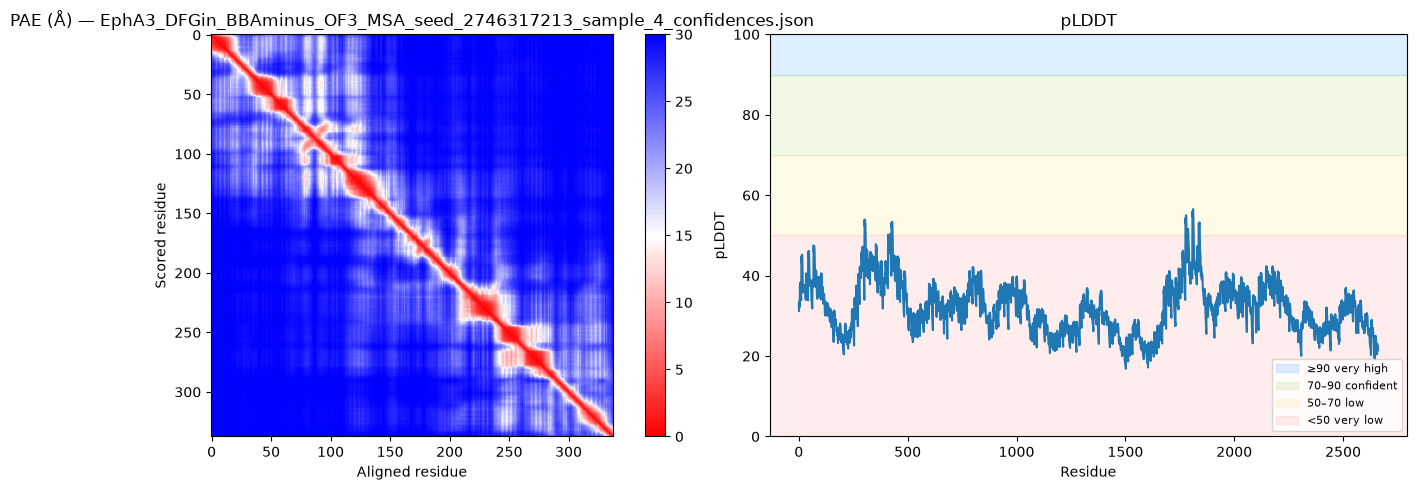

In [14]:
# @title 9. PAE plot for best sample  { display-mode: "form" }
import json
import pathlib

import helpers
import matplotlib.pyplot as plt

output_dir = pathlib.Path(jobname) / "of3_output"
sample_files = sorted(
    f for f in output_dir.rglob("*_confidences.json") if "aggregated" not in f.name
)
if not sample_files:
    raise FileNotFoundError("No confidence JSONs found.")


# Pick the highest-pLDDT sample.
def _mean_plddt(cf):
    with open(cf) as f:
        return helpers.mean_plddt(json.load(f))


best = max(sample_files, key=_mean_plddt)
with open(best) as f:
    d = json.load(f)

pae = helpers.extract_pae(d)
plddt = helpers.extract_plddt(d)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
if pae is not None:
    # helpers.collapse_pae collapses a 3-D aligned_confidence_probs tensor into
    # an expected-PAE matrix; a 2-D PAE passes through unchanged.
    pae = helpers.collapse_pae(pae)
    im = axs[0].imshow(pae, cmap="bwr_r", vmin=0, vmax=30)
    axs[0].set_title(f"PAE (Å) — {best.name}")
    axs[0].set_xlabel("Aligned residue")
    axs[0].set_ylabel("Scored residue")
    plt.colorbar(im, ax=axs[0], fraction=0.046)
else:
    axs[0].text(0.5, 0.5, "no PAE in confidence JSON", ha="center", va="center")
    axs[0].set_axis_off()

if plddt:
    axs[1].plot(plddt, lw=1.5)
    axs[1].axhspan(90, 100, color="#1f8eff", alpha=0.15, label="≥90 very high")
    axs[1].axhspan(70, 90, color="#92d050", alpha=0.15, label="70–90 confident")
    axs[1].axhspan(50, 70, color="#ffd966", alpha=0.15, label="50–70 low")
    axs[1].axhspan(0, 50, color="#ff8a8a", alpha=0.15, label="<50 very low")
    axs[1].set_xlabel("Residue")
    axs[1].set_ylabel("pLDDT")
    axs[1].set_ylim(0, 100)
    axs[1].set_title("pLDDT")
    axs[1].legend(loc="lower right", fontsize=8)
else:
    axs[1].text(0.5, 0.5, "no pLDDT in confidence JSON", ha="center", va="center")
    axs[1].set_axis_off()

plt.tight_layout()
plt.show()

In [15]:
# @title 10. Package + download results

import pathlib
import shutil

result_zip = pathlib.Path(f"{jobname}.result.zip")
if result_zip.exists():
    result_zip.unlink()
shutil.make_archive(jobname + ".result", "zip", root_dir=jobname)
print(f"Archive: {result_zip}  ({result_zip.stat().st_size / 1e6:.1f} MB)")

# Direct-download (Colab only)
try:
    from google.colab import files

    files.download(str(result_zip))
except Exception as e:
    print(f"(Colab direct download not available: {e})")

# Optional Drive upload
if save_to_google_drive:
    try:
        from google.colab import drive

        drive.mount("/content/drive", force_remount=True)
        dest = pathlib.Path("/content/drive/MyDrive") / result_zip.name
        shutil.copy(result_zip, dest)
        print(f"Copied to {dest}")
    except Exception as e:
        print(f"Drive copy failed: {e}")

Archive: EphA3_DFGin_BBAminus_OF3_MSA.result.zip  (5.9 MB)
(Colab direct download not available: No module named 'google.colab')
